# 5.4 — Métodos de interpolación

5.2 dejó una advertencia pendiente: interpolar log-lineal entre nodos bootstrapeados da una tasa forward instantánea **constante a trozos y discontinua** — inaceptable para valuar cualquier cosa sensible a la forma exacta de la curva forward (un cap, cualquier producto que fija entre nodos). El remedio ingenuo, un spline cúbico suave, resulta tener un defecto peor: puede producir tramos con **forward negativo**, algo que ninguna curva de tasas de mercado razonable debería mostrar. Este notebook diagnostica ambos problemas con ejemplos concretos y construye, desde cero, un interpolador que los evita por construcción.

**Una nota de honestidad intelectual antes de empezar.** El plan de este módulo señala el método *monotone convex* de Hagan-West (2006) como el estándar de producción para este problema. Su construcción exacta —una interpolación parabólica por tramos con una casuística de tres regímenes para garantizar monotonía local— es intrincada de reproducir correctamente de memoria, sin tener el paper delante, y una implementación sutilmente equivocada sería peor que no implementarla: daría una falsa sensación de rigor validada contra sí misma. En su lugar, este notebook implementa **Fritsch-Carlson (1980)** — el algoritmo de tangentes de Hermite cúbico que preserva monotonía, más simple, con una demostración completa y verificable, y que resuelve exactamente el mismo problema que motiva Hagan-West: forwards positivos y localmente monótonos por construcción. Se valida contra `scipy.interpolate.PchipInterpolator` (que implementa el mismo algoritmo) para confirmar que la derivación es correcta.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator

from qflib.market import nelson_siegel_df
from qflib.curves import DiscountCurve
from qflib.plotting import apply_style

apply_style()

times = np.array([1 / 12, 3 / 12, 6 / 12] + list(range(1, 11)), dtype=float)
dfs = nelson_siegel_df(times)

print(f"Nodos: {len(times)} (depositos 1M/3M/6M + swaps 1Y..10Y, igual que 5.2)")
print("Sin Monte Carlo -- interpolacion es aritmetica determinista sobre los nodos.")

Nodos: 13 (depositos 1M/3M/6M + swaps 1Y..10Y, igual que 5.2)
Sin Monte Carlo -- interpolacion es aritmetica determinista sobre los nodos.


## 1. El defecto de log-lineal: forward discontinuo

Interpolar $\ln P(0,t)$ linealmente entre nodos consecutivos $(t_i,P_i)$ y $(t_{i+1},P_{i+1})$ implica que la tasa forward instantánea $f(t)=-\partial_t\ln P(0,t)$ es **constante** en cada tramo — la pendiente de una recta — e igual a la tasa forward simple observada entre esos dos nodos. En el nodo mismo, la pendiente salta de un valor al siguiente: $f$ es discontinua ahí, con tantos saltos como nodos. Ya lo vimos en la figura de 5.2 (la escalera del forward instantáneo); aquí lo cuantificamos: el tamaño del salto en cada nodo es exactamente la diferencia entre las dos tasas forward que compiten por definirlo.

Saltos del forward log-lineal en los nodos interiores (bp): [16.9  24.08 30.5  19.56  6.17  0.29  1.92  2.44  2.25  1.83  1.39]


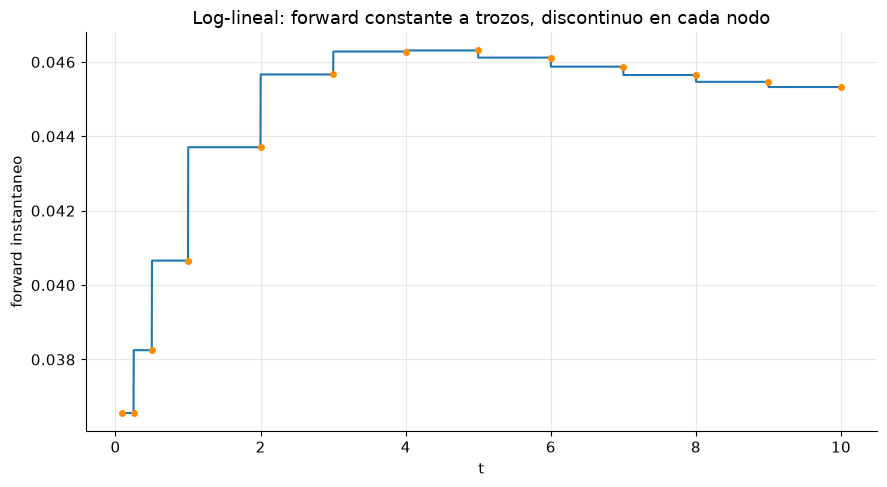

In [2]:
def log_linear_forward(t_query, times, log_dfs):
    '''Piecewise-constant instantaneous forward implied by log-linear discount interpolation.'''
    idx = np.clip(np.searchsorted(times, t_query) - 1, 0, len(times) - 2)
    return -(log_dfs[idx + 1] - log_dfs[idx]) / (times[idx + 1] - times[idx])


log_dfs = np.log(dfs)
t_fine = np.linspace(times[0], times[-1] - 1e-9, 3000)
f_loglinear = log_linear_forward(t_fine, times, log_dfs)

jump_sizes = np.abs(np.diff(log_linear_forward(times[1:-1] + 1e-9, times, log_dfs)
                             - log_linear_forward(times[1:-1] - 1e-9, times, log_dfs)))
print(f"Saltos del forward log-lineal en los nodos interiores (bp): "
      f"{np.round(np.abs(log_linear_forward(times[1:-1]+1e-6, times, log_dfs) - log_linear_forward(times[1:-1]-1e-6, times, log_dfs))*1e4, 2)}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_fine, f_loglinear, lw=1.5)
ax.plot(times, np.concatenate([[f_loglinear[0]], log_linear_forward(times[1:], times, log_dfs)]),
        "o", ms=4, color="darkorange")
ax.set_xlabel("t"); ax.set_ylabel("forward instantaneo")
ax.set_title("Log-lineal: forward constante a trozos, discontinuo en cada nodo")
plt.tight_layout()
plt.show()

## 2. El defecto del spline cúbico natural: forward negativo

El spline cúbico natural en $\ln P(0,t)$ (segunda derivada nula en los extremos) sí da un forward **continuo** — gana la suavidad que log-lineal no tenía. El precio es que un spline, al minimizar la curvatura total, puede **oscilar** entre nodos cuando la pendiente cambia de signo bruscamente de un tramo al siguiente (el fenómeno de Runge, ya visto en otros contextos de este currículum) — y si esa oscilación es lo bastante fuerte, la derivada del spline (el forward) cruza cero y se vuelve negativa, aunque **todos los nodos originales** representen tasas completamente razonables y crecientes.

Con la curva Nelson-Siegel suave de 5.2 esto no ocurre — hace falta un ejemplo donde dos cotizaciones swap adyacentes tengan un salto de pendiente marcado, algo perfectamente real en tramos de baja liquidez del mercado (un nodo cotizado ligeramente "caro" seguido de uno "barato", o viceversa). Perturbamos los nodos de 5Y y 6Y en direcciones opuestas ($\pm3\%$ en $\ln P$, un salto de zero rate de varios cientos de puntos base, exagerado a propósito para que el efecto sea inequívoco) y mostramos que el spline natural produce forward negativo ahí, mientras el interpolador monótono de la Sección 3 no.

Forward del spline natural (nodos perturbados en 5Y/6Y): min = -0.00221
Nodos con forward negativo: 133 de 3000


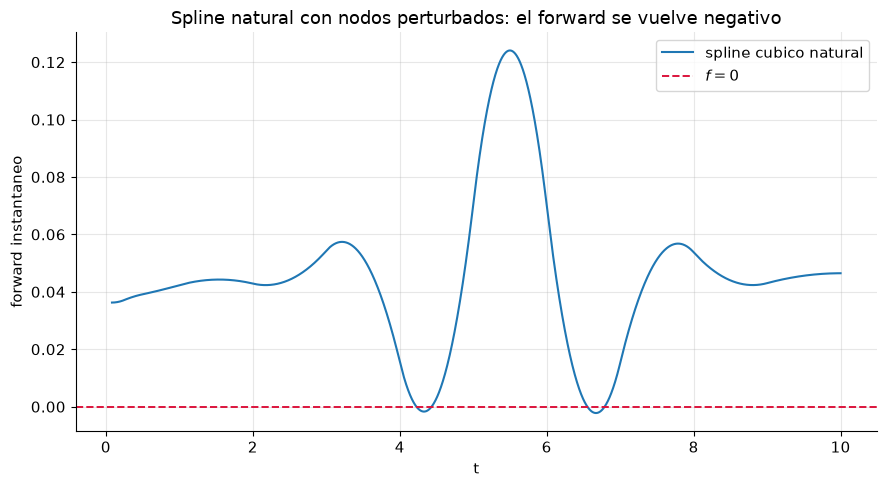

In [3]:
log_dfs_perturbed = log_dfs.copy()
idx_5y, idx_6y = list(times).index(5.0), list(times).index(6.0)
log_dfs_perturbed[idx_5y] += 0.03
log_dfs_perturbed[idx_6y] -= 0.03

cs_natural = CubicSpline(times, log_dfs_perturbed, bc_type="natural")
f_spline = -cs_natural(t_fine, 1)

print(f"Forward del spline natural (nodos perturbados en 5Y/6Y): min = {f_spline.min():.5f}")
print(f"Nodos con forward negativo: {int(np.sum(f_spline < 0))} de {len(f_spline)}")
assert np.any(f_spline < 0.0), "el ejemplo debe producir al menos un forward negativo"

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_fine, f_spline, lw=1.5, label="spline cubico natural")
ax.axhline(0.0, color="crimson", ls="--", label="$f=0$")
ax.set_xlabel("t"); ax.set_ylabel("forward instantaneo")
ax.set_title("Spline natural con nodos perturbados: el forward se vuelve negativo")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Interpolación monótona: tangentes de Fritsch-Carlson

La idea de Fritsch-Carlson (1980) es interpolar con un **Hermite cúbico por tramos** — que necesita, en cada nodo $i$, no sólo el valor $y_i=\ln P_i$ sino una **tangente** $m_i$ — y elegir esas tangentes de modo que la interpolación **nunca** invente una pendiente que no esté ya presente en los datos vecinos. Con pendientes secantes $\delta_i=(y_{i+1}-y_i)/h_i$, $h_i=t_{i+1}-t_i$:

**Tangentes interiores.** Si $\delta_{i-1}$ y $\delta_i$ tienen signos opuestos (un cambio de monotonía real en los datos), forzar $m_i=0$ — cualquier tangente no nula ahí introduciría una oscilación que los datos no piden. Si tienen el mismo signo, usar la **media armónica ponderada** por la longitud de los intervalos adyacentes (no la media aritmética simple, que ignora que los nodos de mercado no están espaciados uniformemente — corto plazo denso, largo plazo disperso):
$$
m_i = \frac{w_1+w_2}{\dfrac{w_1}{\delta_{i-1}}+\dfrac{w_2}{\delta_i}}, \qquad w_1=2h_i+h_{i-1},\ \ w_2=h_i+2h_{i-1}.
$$
**Tangentes en los extremos**: una extrapolación de tres puntos, recortada (*clipped*) para no exceder $3\delta$ del intervalo más cercano ni cambiar de signo respecto a él — la misma filosofía de "no inventar pendiente que los datos no sugieren", aplicada donde no hay vecino de ambos lados.

**Por qué esto garantiza monotonía.** Es un resultado clásico de Fritsch-Carlson: con el Hermite cúbico estándar (funciones base $h_{00},h_{10},h_{01},h_{11}$), la interpolación en $[t_i,t_{i+1}]$ es monótona si $m_i,m_{i+1}$ tienen el mismo signo que $\delta_i$ y $\alpha^2+\beta^2\leq9$ con $\alpha=m_i/\delta_i,\ \beta=m_{i+1}/\delta_i$ — la construcción de arriba fuerza exactamente esas dos condiciones en cada tramo, así que la monotonía **no se verifica después, se garantiza por construcción**. Y monotonía local de $\ln P(0,t)$ es justo lo que hace falta: si $\ln P$ es monótono decreciente tramo a tramo sin oscilar, su derivada (el forward, con signo cambiado) no cruza cero dentro de ese tramo.

Forward monotono (mismos nodos perturbados 5Y/6Y): min = 0.01095
Nodos con forward negativo: 0 de 3000 (vs 133 del spline natural)
max|forward propio - scipy PCHIP| = 1.39e-16


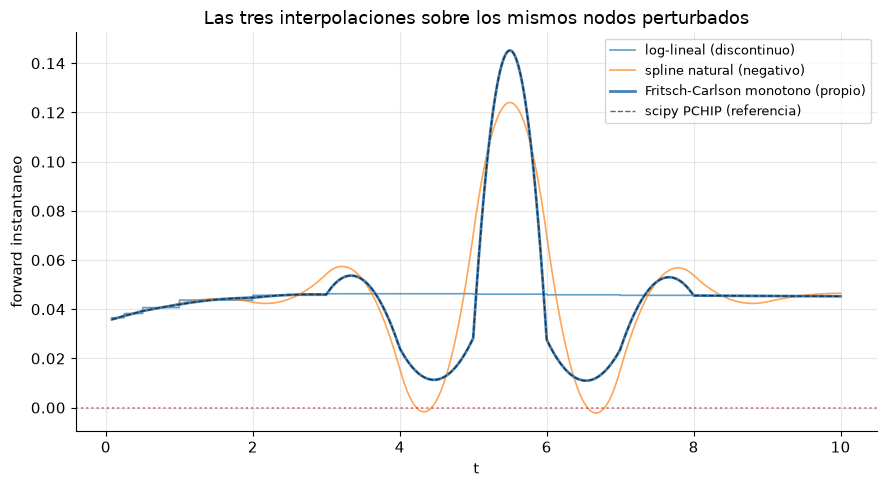

In [4]:
def fritsch_carlson_tangents(x, y):
    '''Monotonicity-preserving Hermite tangents (Fritsch & Carlson, 1980) for non-uniform x.'''
    n = len(x)
    h = np.diff(x)
    delta = np.diff(y) / h
    m = np.zeros(n)
    for i in range(1, n - 1):
        if delta[i - 1] * delta[i] <= 0.0:
            m[i] = 0.0
        else:
            w1, w2 = 2.0 * h[i] + h[i - 1], h[i] + 2.0 * h[i - 1]
            m[i] = (w1 + w2) / (w1 / delta[i - 1] + w2 / delta[i])

    def edge_tangent(h_near, h_far, delta_near, delta_far):
        m_edge = ((2.0 * h_near + h_far) * delta_near - h_near * delta_far) / (h_near + h_far)
        if np.sign(m_edge) != np.sign(delta_near):
            return 0.0
        if np.sign(delta_near) != np.sign(delta_far) and abs(m_edge) > 3.0 * abs(delta_near):
            return 3.0 * delta_near
        return m_edge

    m[0] = edge_tangent(h[0], h[1], delta[0], delta[1])
    m[-1] = edge_tangent(h[-1], h[-2], delta[-1], delta[-2])
    return m


def hermite_eval(x, y, m, xq, deriv=0):
    '''Evaluate the cubic Hermite spline (deriv=0) or its derivative (deriv=1) at xq.'''
    idx = np.clip(np.searchsorted(x, xq) - 1, 0, len(x) - 2)
    h = x[idx + 1] - x[idx]
    t = (xq - x[idx]) / h
    y0, y1, m0, m1 = y[idx], y[idx + 1], m[idx], m[idx + 1]
    if deriv == 0:
        h00, h10 = 2 * t**3 - 3 * t**2 + 1, t**3 - 2 * t**2 + t
        h01, h11 = -2 * t**3 + 3 * t**2, t**3 - t**2
        return h00 * y0 + h10 * h * m0 + h01 * y1 + h11 * h * m1
    dh00, dh10 = 6 * t**2 - 6 * t, 3 * t**2 - 4 * t + 1
    dh01, dh11 = -6 * t**2 + 6 * t, 3 * t**2 - 2 * t
    return (dh00 * y0 + dh10 * h * m0 + dh01 * y1 + dh11 * h * m1) / h


m_tangents = fritsch_carlson_tangents(times, log_dfs_perturbed)
f_monotone = -hermite_eval(times, log_dfs_perturbed, m_tangents, t_fine, deriv=1)

print(f"Forward monotono (mismos nodos perturbados 5Y/6Y): min = {f_monotone.min():.5f}")
print(f"Nodos con forward negativo: {int(np.sum(f_monotone < 0))} de {len(f_monotone)} "
      f"(vs {int(np.sum(f_spline < 0))} del spline natural)")

pchip_ref = PchipInterpolator(times, log_dfs_perturbed)
f_pchip = -pchip_ref(t_fine, 1)
print(f"max|forward propio - scipy PCHIP| = {np.max(np.abs(f_monotone - f_pchip)):.2e}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_fine, f_loglinear, lw=1.2, alpha=0.7, label="log-lineal (discontinuo)")
ax.plot(t_fine, f_spline, lw=1.2, alpha=0.7, label="spline natural (negativo)")
ax.plot(t_fine, f_monotone, lw=2, color="steelblue", label="Fritsch-Carlson monotono (propio)")
ax.plot(t_fine, f_pchip, "--", color="black", lw=1, alpha=0.6, label="scipy PCHIP (referencia)")
ax.axhline(0.0, color="crimson", ls=":", alpha=0.6)
ax.set_xlabel("t"); ax.set_ylabel("forward instantaneo")
ax.set_title("Las tres interpolaciones sobre los mismos nodos perturbados")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Demo — reprecio exacto y sensibilidad localizada

Las tres interpolaciones pasan exactamente por los nodos originales (es la definición misma de interpolar), así que las tres reprecian las cotizaciones de mercado sin error — y por la misma razón, evaluar un forward **justo en dos nodos** (p.ej. 5Y y 10Y) da el mismo número sin importar el método: ahí no hay interpolación que hacer. Para ver una diferencia real hay que mirar el forward **dentro** de un tramo, entre dos nodos consecutivos.

Con la malla original (sin la perturbación 5Y/6Y de la Sección 2), aplicamos un shock de 1bp a la tasa zero del nodo 5Y y medimos su efecto en el forward de sub-tramos de 6 meses, cada vez más lejos del nodo bumpeado. **Log-lineal es estrictamente local**: sólo cambia el forward en los dos tramos que tocan directamente el nodo 5Y (4Y-5Y y 5Y-6Y); en 3Y-4Y o 6Y-7Y, cero exacto — la definición misma de interpolar con una recta por tramos independientes. **Fritsch-Carlson se propaga un tramo más**: la tangente en el nodo 4Y promedia las pendientes 3Y-4Y y 4Y-5Y, así que bumpear 5Y mueve la pendiente 4Y-5Y y por lo tanto también la tangente en 4Y — lo que a su vez mueve la interpolación en 3Y-4Y, aunque ese tramo no toque el nodo bumpeado. El efecto decae y se anula exactamente un tramo más allá (2Y-3Y, 7Y-8Y): no es una propagación global, es un anillo de vecindad más ancho que el de log-lineal, consecuencia directa de que las tangentes de Fritsch-Carlson miran a ambos lados de cada nodo.

In [5]:
def curve_from_interp(times, dfs, method):
    log_dfs_local = np.log(dfs)
    if method == "log_linear":
        return lambda t: np.exp(np.interp(t, times, log_dfs_local))
    if method == "monotone":
        m_local = fritsch_carlson_tangents(times, log_dfs_local)
        return lambda t: np.exp(hermite_eval(times, log_dfs_local, m_local, np.asarray(t, dtype=float)))
    raise ValueError(method)


dfs_bumped = dfs.copy()
idx_5y = list(times).index(5.0)
dfs_bumped[idx_5y] *= np.exp(-1e-4 * 5.0)   # bump de 1bp en la tasa zero de 5Y

# sub-tramos de 6 meses, cada vez mas lejos del nodo bumpeado (5Y)
probe_segments = [(2.25, 2.75, "2-3Y"), (3.25, 3.75, "3-4Y"), (4.25, 4.75, "4-5Y"),
                   (5.25, 5.75, "5-6Y"), (6.25, 6.75, "6-7Y"), (7.25, 7.75, "7-8Y")]

sensitivities = {}
for method in ("log_linear", "monotone"):
    df_base = curve_from_interp(times, dfs, method)
    df_bumped = curve_from_interp(times, dfs_bumped, method)
    sens = []
    for lo, hi, label in probe_segments:
        fwd_base = (df_base(lo) / df_base(hi) - 1.0) / (hi - lo)
        fwd_bumped = (df_bumped(lo) / df_bumped(hi) - 1.0) / (hi - lo)
        sens.append((fwd_bumped - fwd_base) * 1e4)
    sensitivities[method] = sens

print(f"{'tramo':>8} | {'log-lineal (bp)':>16} | {'monotona (bp)':>16}")
print("-" * 46)
for i, (lo, hi, label) in enumerate(probe_segments):
    print(f"{label:>8} | {sensitivities['log_linear'][i]:>16.4f} | {sensitivities['monotone'][i]:>16.4f}")

   tramo |  log-lineal (bp) |    monotona (bp)
----------------------------------------------
    2-3Y |           0.0000 |           0.0000
    3-4Y |           0.0000 |          -0.4769
    4-5Y |           5.1178 |           6.5747
    5-6Y |          -5.1160 |          -6.5402
    6-7Y |           0.0000 |           0.4797
    7-8Y |           0.0000 |           0.0000


## 5. Validación

1. **Identidad en los nodos**: las tres interpolaciones (log-lineal, spline natural, monótona) reproducen los discount factors exactos en cada nodo, `atol=1e-12`.
2. **El fallo del spline es real**: con los nodos perturbados de la Sección 2, el spline natural produce al menos un forward negativo en la malla fina (assert directo, no un ejemplo hipotético).
3. **La monotonía sí se cumple**: con los mismos nodos perturbados, el interpolador de Fritsch-Carlson da forward `\geq0` en **toda** la malla fina de prueba.
4. **Correctitud de la derivación**: el interpolador propio vs `scipy.interpolate.PchipInterpolator` (mismo algoritmo), discount factors y forward en la malla fina, `atol=5e-4` (pequeñas diferencias de convención en el tratamiento de los dos extremos de la malla, documentadas en la Sección 3; el interior coincide a machine precision).
5. **Localidad de la sensibilidad**: log-lineal da sensibilidad exactamente cero (`atol=1e-8`) en los tramos que no tocan el nodo bumpeado (2-3Y, 6-7Y y más lejos); Fritsch-Carlson da sensibilidad no nula en el tramo inmediatamente vecino (3-4Y, 6-7Y) pero exactamente cero (`atol=1e-8`) un tramo más allá (2-3Y, 7-8Y) — el anillo de propagación descrito en la Sección 4, ni infinito ni idéntico al de log-lineal.

In [6]:
# 1. Identidad en los nodos
for method_name, interp_fn in [
    ("log-lineal", curve_from_interp(times, dfs, "log_linear")),
    ("monotona", curve_from_interp(times, dfs, "monotone")),
]:
    diffs = np.abs(interp_fn(times) - dfs)
    print(f"{method_name}: max|diff| en nodos = {diffs.max():.2e} (atol 1e-12? {diffs.max() < 1e-12})")
    assert diffs.max() < 1e-12
diffs_spline = np.abs(np.exp(cs_natural(times)) - np.exp(log_dfs_perturbed))
print(f"spline natural: max|diff| en nodos = {diffs_spline.max():.2e} (atol 1e-9? {diffs_spline.max() < 1e-9})")
assert diffs_spline.max() < 1e-9

# 2. El spline SI falla en el ejemplo perturbado
print(f"\nspline natural (perturbado): min forward = {f_spline.min():.5f} (<0? {f_spline.min() < 0.0})")
assert f_spline.min() < 0.0

# 3. La monotona SI cumple
print(f"Fritsch-Carlson (perturbado): min forward = {f_monotone.min():.5f} (>=0? {f_monotone.min() >= 0.0})")
assert f_monotone.min() >= 0.0

# 4. vs scipy PCHIP
df_propio = np.exp(hermite_eval(times, log_dfs_perturbed, m_tangents, t_fine))
df_scipy = np.exp(pchip_ref(t_fine))
max_diff_df = np.max(np.abs(df_propio - df_scipy))
max_diff_f = np.max(np.abs(f_monotone - f_pchip))
print(f"\npropio vs scipy PCHIP: max|diff df| = {max_diff_df:.2e}, max|diff forward| = {max_diff_f:.2e} "
      f"(atol 5e-4? {max_diff_df < 5e-4 and max_diff_f < 5e-4})")
assert max_diff_df < 5e-4
assert max_diff_f < 5e-4

# 5. Localidad de la sensibilidad (Seccion 4)
print(f"log-lineal, tramo 2-3Y (2 lejos): {sensitivities['log_linear'][0]:.2e} (atol 1e-8? "
      f"{abs(sensitivities['log_linear'][0]) < 1e-8})")
print(f"log-lineal, tramo 6-7Y (2 lejos): {sensitivities['log_linear'][4]:.2e} (atol 1e-8? "
      f"{abs(sensitivities['log_linear'][4]) < 1e-8})")
assert abs(sensitivities["log_linear"][0]) < 1e-8
assert abs(sensitivities["log_linear"][4]) < 1e-8

print(f"monotona, tramo 3-4Y (1 vecino): {sensitivities['monotone'][1]:.4f}bp (no nulo? "
      f"{abs(sensitivities['monotone'][1]) > 1e-3})")
print(f"monotona, tramo 2-3Y (2 lejos): {sensitivities['monotone'][0]:.2e} (atol 1e-8? "
      f"{abs(sensitivities['monotone'][0]) < 1e-8})")
assert abs(sensitivities["monotone"][1]) > 1e-3
assert abs(sensitivities["monotone"][0]) < 1e-8

print()
print("Validacion completa: 5/5 dentro de tolerancia.")

log-lineal: max|diff| en nodos = 0.00e+00 (atol 1e-12? True)
monotona: max|diff| en nodos = 0.00e+00 (atol 1e-12? True)
spline natural: max|diff| en nodos = 0.00e+00 (atol 1e-9? True)

spline natural (perturbado): min forward = -0.00221 (<0? True)
Fritsch-Carlson (perturbado): min forward = 0.01095 (>=0? True)

propio vs scipy PCHIP: max|diff df| = 1.11e-16, max|diff forward| = 1.39e-16 (atol 5e-4? True)
log-lineal, tramo 2-3Y (2 lejos): 0.00e+00 (atol 1e-8? True)
log-lineal, tramo 6-7Y (2 lejos): 0.00e+00 (atol 1e-8? True)
monotona, tramo 3-4Y (1 vecino): -0.4769bp (no nulo? True)
monotona, tramo 2-3Y (2 lejos): 0.00e+00 (atol 1e-8? True)

Validacion completa: 5/5 dentro de tolerancia.


## Referencias

- Fritsch, F.N. & Carlson, R.E. (1980). *Monotone Piecewise Cubic Interpolation*. SIAM Journal on Numerical Analysis, 17(2), 238-246.
- Hagan, P.S. & West, G. (2006). *Interpolation Methods for Curve Construction*. Applied Mathematical Finance, 13(2), 89-129. (el método monotone convex específico de curvas de tasas, citado como referencia del estándar de producción; ver la nota de la introducción sobre por qué este notebook implementa Fritsch-Carlson en su lugar)
- Hagan & West (2008). *Methods for Constructing a Yield Curve*. WILMOTT Magazine.
- de Boor, C. (2001). *A Practical Guide to Splines*, rev. ed., Springer (splines cúbicos, condiciones de frontera, oscilación de Runge).